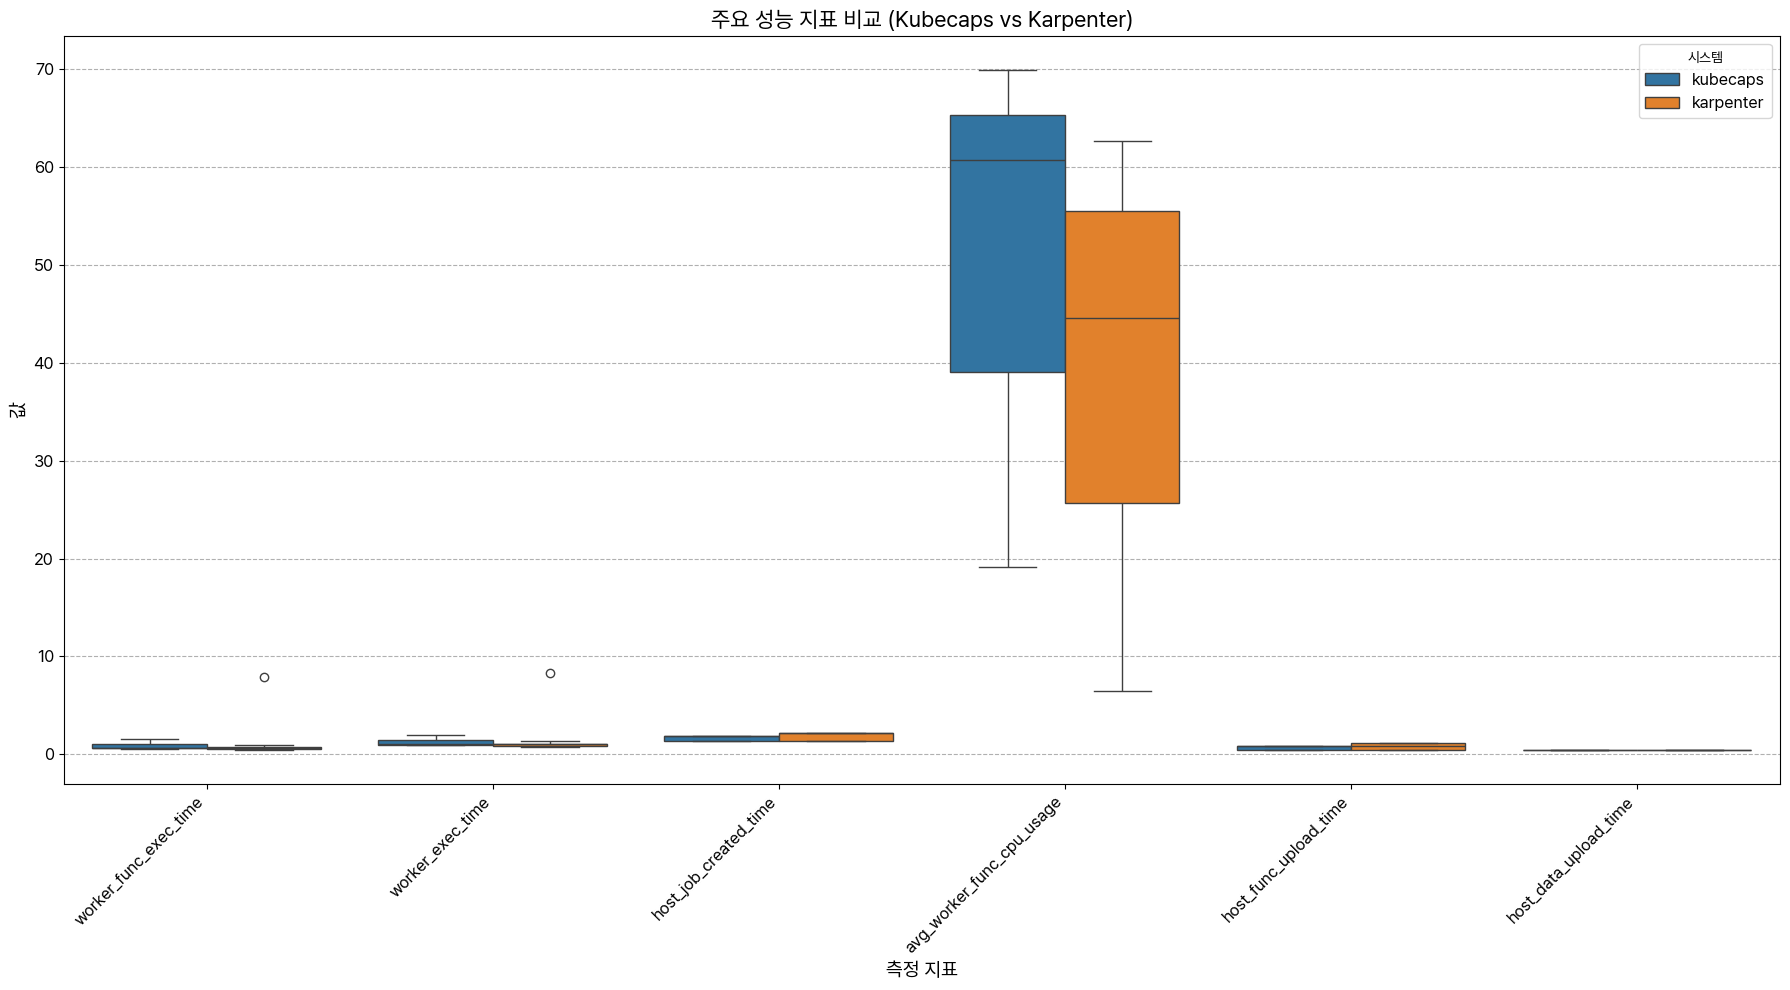

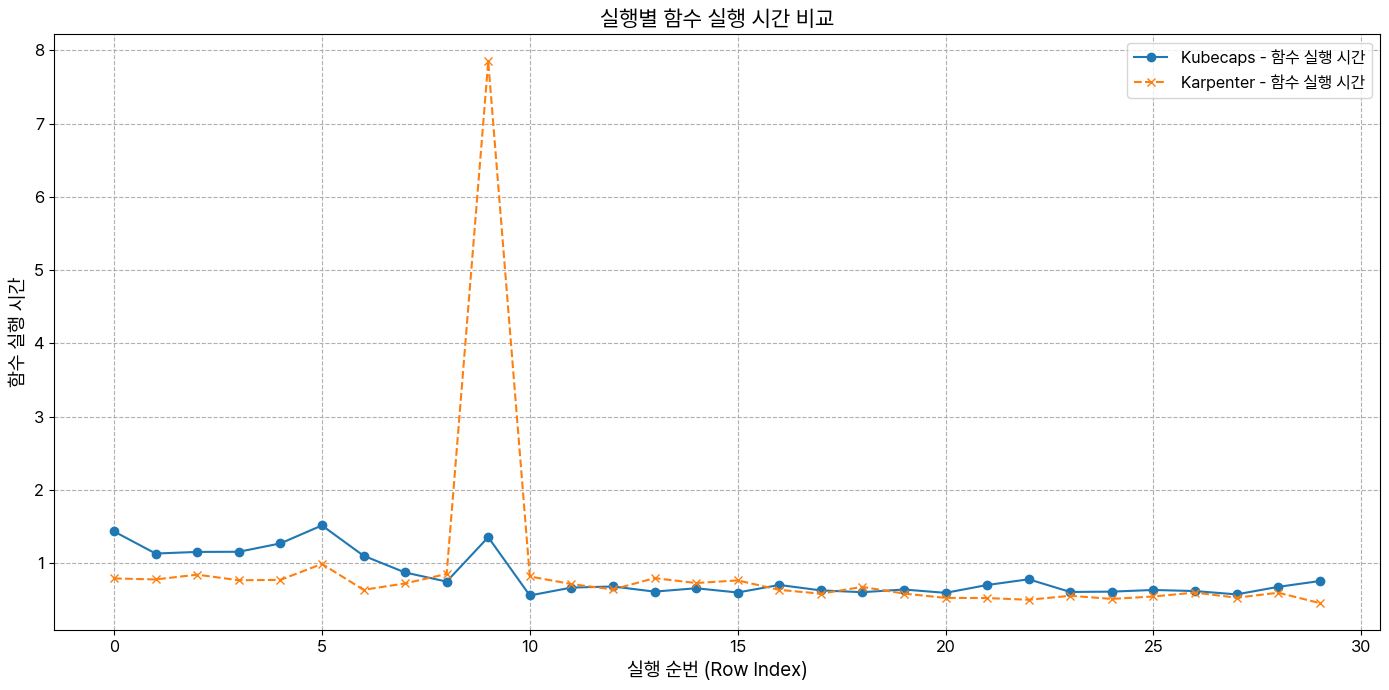

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import numpy as np

plt.rcParams['font.family'] = 'Pretendard'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

# 파일 경로 설정
file_kubecaps = '../results/1_8_30/5a6b8c8c-5d3a-4537-ac1c-15ac1306b611/stats.csv'
file_karpenter = '../results/1_8_30/8d4e1aeb-3d4a-4c60-96be-4d66f447f21f/stats.csv'

# 데이터 로드
try:
    df_kubecaps = pd.read_csv(file_kubecaps)
    df_karpenter = pd.read_csv(file_karpenter)
except FileNotFoundError:
    print(f"오류: CSV 파일을 찾을 수 없습니다. 경로를 확인하세요: \n{file_kubecaps}\n{file_karpenter}")
    # 파일이 없으면 이후 코드 실행 중단 (혹은 적절한 예외 처리)
    raise

# 라벨 추가
df_kubecaps['label'] = 'kubecaps'
df_karpenter['label'] = 'karpenter'

# "같은 row끼리 비교"를 위해 짧은 쪽 데이터프레임 길이에 맞춤
min_rows = min(len(df_kubecaps), len(df_karpenter))
df_kubecaps_trimmed = df_kubecaps.iloc[:min_rows].copy()
df_karpenter_trimmed = df_karpenter.iloc[:min_rows].copy()

if min_rows == 0:
    print("오류: 비교할 데이터가 없습니다 (파일 중 하나 이상이 비어있거나 헤더만 있을 수 있습니다).")
else:
    # worker_func_cpu_usage 처리 함수
    def parse_and_mean_cpu_usage(series):
        means = []
        for s in series:
            try:
                if pd.isna(s):
                    means.append(np.nan)
                    continue
                # 문자열 형태의 리스트를 실제 리스트로 변환
                data_list = ast.literal_eval(s)
                if data_list and all(isinstance(x, (int, float)) for x in data_list):
                    means.append(np.mean(data_list))
                else:
                    means.append(np.nan) # 비어있거나 숫자가 아닌 요소가 포함된 경우
            except (ValueError, SyntaxError, TypeError):
                means.append(np.nan) # 파싱 실패 또는 부적절한 타입
        return pd.Series(means, index=series.index) # 원래 인덱스 유지

    # 각 DataFrame에 대해 CPU 사용량 평균 계산
    if 'worker_func_cpu_usage' in df_kubecaps_trimmed.columns:
        df_kubecaps_trimmed.loc[:, 'avg_worker_func_cpu_usage'] = parse_and_mean_cpu_usage(df_kubecaps_trimmed['worker_func_cpu_usage'])
    else:
        df_kubecaps_trimmed.loc[:, 'avg_worker_func_cpu_usage'] = np.nan
        print("경고: Kubecaps 데이터에 'worker_func_cpu_usage' 열이 없습니다.")

    if 'worker_func_cpu_usage' in df_karpenter_trimmed.columns:
        df_karpenter_trimmed.loc[:, 'avg_worker_func_cpu_usage'] = parse_and_mean_cpu_usage(df_karpenter_trimmed['worker_func_cpu_usage'])
    else:
        df_karpenter_trimmed.loc[:, 'avg_worker_func_cpu_usage'] = np.nan
        print("경고: Karpenter 데이터에 'worker_func_cpu_usage' 열이 없습니다.")

    # 비교할 주요 수치형 열 목록
    comparison_cols_numeric = [
        'worker_func_exec_time',    # 함수 실행 시간
        'worker_exec_time',         # 워커 전체 실행 시간
        'host_job_created_time',    # 작업 생성 소요 시간
        'avg_worker_func_cpu_usage',# 평균 워커 함수 CPU 사용률
        'host_func_upload_time',    # 함수 업로드 시간
        'host_data_upload_time'     # 데이터 업로드 시간
    ]

    # 시각화를 위한 데이터 준비 (수치형 데이터)
    plot_data_list = []
    for col in comparison_cols_numeric:
        # kubecaps 데이터
        if col in df_kubecaps_trimmed.columns:
            temp_kubecaps = df_kubecaps_trimmed[[col]].copy()
            temp_kubecaps['label'] = 'kubecaps'
            temp_kubecaps.rename(columns={col: 'value'}, inplace=True)
            temp_kubecaps['metric'] = col
            plot_data_list.append(temp_kubecaps)
        else:
            print(f"경고: Kubecaps 데이터에 '{col}' 열이 없어 해당 지표 비교에서 제외됩니다.")

        # karpenter 데이터
        if col in df_karpenter_trimmed.columns:
            temp_karpenter = df_karpenter_trimmed[[col]].copy()
            temp_karpenter['label'] = 'karpenter'
            temp_karpenter.rename(columns={col: 'value'}, inplace=True)
            temp_karpenter['metric'] = col
            plot_data_list.append(temp_karpenter)
        else:
            print(f"경고: Karpenter 데이터에 '{col}' 열이 없어 해당 지표 비교에서 제외됩니다.")
            
    if plot_data_list:
        combined_numeric_data = pd.concat(plot_data_list)
        combined_numeric_data.dropna(subset=['value'], inplace=True) # NaN 값 제거

        if not combined_numeric_data.empty:
            # 수치형 데이터 시각화 (박스 플롯)
            plt.figure(figsize=(18, 10))
            sns.boxplot(x='metric', y='value', hue='label', data=combined_numeric_data)
            plt.xticks(rotation=45, ha='right', fontsize=12)
            plt.yticks(fontsize=12)
            plt.xlabel("측정 지표", fontsize=14)
            plt.ylabel("값", fontsize=14)
            plt.title('주요 성능 지표 비교 (Kubecaps vs Karpenter)', fontsize=16)
            plt.legend(title='시스템', fontsize=12)
            plt.grid(True, axis='y', linestyle='--')
            plt.tight_layout()
            plt.show()
        else:
            print("시각화할 수치형 데이터가 없습니다 (모든 값이 NaN일 수 있습니다).")
    else:
        print("비교할 공통 수치형 지표가 없습니다.")


    # 각 실행(row)별 'worker_func_exec_time' 비교 (라인 플롯)
    if 'worker_func_exec_time' in df_kubecaps_trimmed.columns and \
       'worker_func_exec_time' in df_karpenter_trimmed.columns:
        
        df_comparison = pd.DataFrame({
            'kubecaps_exec_time': df_kubecaps_trimmed['worker_func_exec_time'],
            'karpenter_exec_time': df_karpenter_trimmed['worker_func_exec_time']
        }).reset_index() # 실행 순서(인덱스)를 x축으로 사용

        if not df_comparison.empty:
            plt.figure(figsize=(14, 7))
            plt.plot(df_comparison.index, df_comparison['kubecaps_exec_time'], 
                     label='Kubecaps - 함수 실행 시간', marker='o', linestyle='-')
            plt.plot(df_comparison.index, df_comparison['karpenter_exec_time'], 
                     label='Karpenter - 함수 실행 시간', marker='x', linestyle='--')
            
            plt.xlabel('실행 순번 (Row Index)', fontsize=14)
            plt.ylabel('함수 실행 시간', fontsize=14)
            plt.title('실행별 함수 실행 시간 비교', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.legend(fontsize=12)
            plt.grid(True, linestyle='--')
            plt.tight_layout()
            plt.show()
        else:
            print("실행별 함수 실행 시간 비교를 위한 데이터가 없습니다.")
    else:
        print("경고: 'worker_func_exec_time' 열이 없어 실행별 비교를 할 수 없습니다.")


In [18]:

# 계산된 total_time 컬럼 확인 (선택 사항)
print("df_kubecaps_trimmed 'total_time' 컬럼 샘플:")
print(df_kubecaps_trimmed['worker_exec_time'].sum())
print("\ndf_karpenter_trimmed 'total_time' 컬럼 샘플:")
print(df_karpenter_trimmed['worker_exec_time'].sum())

df_kubecaps_trimmed 'total_time' 컬럼 샘플:
36.4791291

df_karpenter_trimmed 'total_time' 컬럼 샘플:
36.82424592


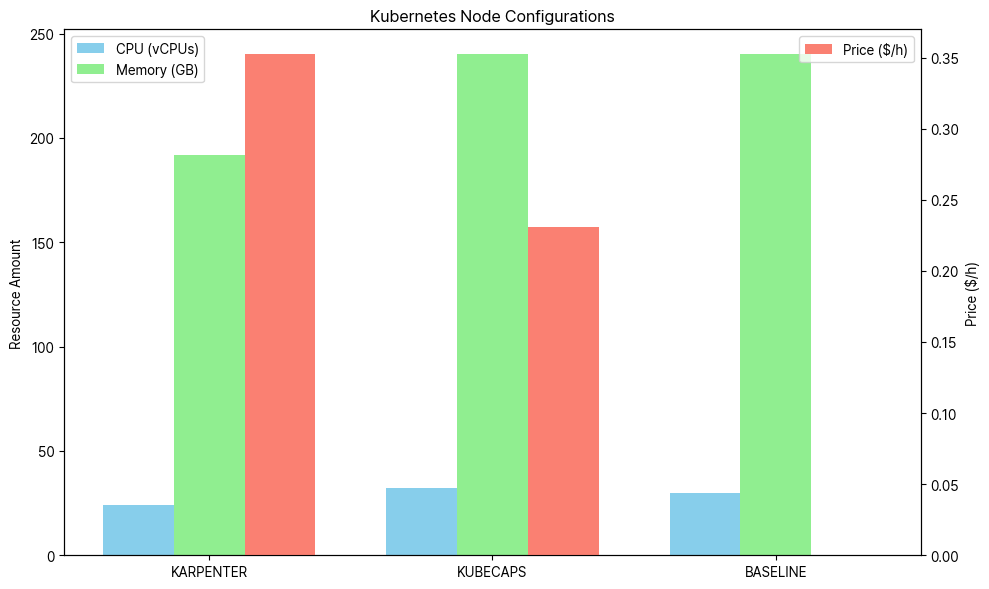

In [24]:

import matplotlib.pyplot as plt
import numpy as np

# 데이터 정의
configs = ['KARPENTER', 'KUBECAPS', 'BASELINE']
cpus = [24, 32, 30]
mems = [192, 240, 240]
prices = [0.3522, 0.231, 0.0]  # BASELINE은 가격 없음

x = np.arange(len(configs))  # x축 위치
width = 0.25  # 막대 폭

# 시각화
fig, ax1 = plt.subplots(figsize=(10, 6))

# CPU, MEM 막대
bar1 = ax1.bar(x - width, cpus, width, label='CPU (vCPUs)', color='skyblue')
bar2 = ax1.bar(x, mems, width, label='Memory (GB)', color='lightgreen')
ax1.set_ylabel('Resource Amount')
ax1.set_title('Kubernetes Node Configurations')
ax1.set_xticks(x)
ax1.set_xticklabels(configs)
ax1.legend(loc='upper left')

# 가격 축 (우측 Y축)
ax2 = ax1.twinx()
bar3 = ax2.bar(x + width, prices, width, label='Price ($/h)', color='salmon')
ax2.set_ylabel('Price ($/h)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# KARPENTER CPU 24 MEM 192 PRICE 0.3522
# KUBECAPS CPU 32 MEM 240 PRICE 0.231
# BASELINE CPU 30 MEM 240
